In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

backtest_returns = pd.read_csv("../data/processed/backtest_returns_net.csv", index_col=0, parse_dates=True)

backtest_returns.head()

,Equal Weight,Minimum Variance,Maximum Sharpe,Risk Parity,SPY Benchmark
2016-01-05,0.002666,-0.000240,-0.001736,0.001293,0.001691
2016-01-06,-0.004106,0.002448,-0.009611,0.000425,-0.012614
2016-01-07,-0.015195,-0.006126,-0.031331,-0.009636,-0.023992
2016-01-08,-0.008812,-0.004806,-0.008110,-0.006158,-0.010977
2016-01-11,-0.001462,-0.006157,0.003078,-0.003878,0.000990


In [2]:
trading_days = 252

def period_return(returns):
    return (1 + returns).prod() - 1

def annualized_volatility(returns):
    return returns.std() * np.sqrt(trading_days)

def max_drawdown(returns):
    cumulative = (1 + returns).cumprod()
    running_max = cumulative.cummax()
    drawdown = cumulative / running_max - 1
    return drawdown.min()

def historical_var(returns, confidence_level=0.95):
    return returns.quantile(1 - confidence_level)

def historical_cvar(returns, confidence_level=0.95):
    var = historical_var(returns, confidence_level)
    return returns[returns <= var].mean()

In [3]:
stress_periods = {
    "COVID Crash": ("2020-02-19", "2020-03-23"),
    "2022 Rate Hike Period": ("2022-01-03", "2022-10-14")
}

In [4]:
stress_results = {}

for period_name, (start_date, end_date) in stress_periods.items():
    period_data = backtest_returns.loc[start_date:end_date]
    
    metrics = pd.DataFrame(index=period_data.columns)
    metrics["Period Return"] = period_data.apply(period_return)
    metrics["Annualized Volatility"] = period_data.apply(annualized_volatility)
    metrics["Maximum Drawdown"] = period_data.apply(max_drawdown)
    metrics["95% Historical VaR"] = period_data.apply(historical_var)
    metrics["95% Historical CVaR"] = period_data.apply(historical_cvar)
    
    stress_results[period_name] = metrics
    
    print("=" * 80)
    print(period_name)
    display(metrics)

COVID Crash


,Period Return,Annualized Volatility,Maximum Drawdown,95% Historical VaR,95% Historical CVaR
Equal Weight,-0.250058,0.523338,-0.252417,-0.074205,-0.080843
Minimum Variance,-0.135737,0.340343,-0.187700,-0.051263,-0.053905
Maximum Sharpe,-0.064652,0.280444,-0.126249,-0.034943,-0.037756
Risk Parity,-0.173443,0.372046,-0.201588,-0.051944,-0.055657
SPY Benchmark,-0.337897,0.755206,-0.341047,-0.093040,-0.102550


2022 Rate Hike Period


,Period Return,Annualized Volatility,Maximum Drawdown,95% Historical VaR,95% Historical CVaR
Equal Weight,-0.270426,0.184421,-0.268894,-0.019959,-0.026412
Minimum Variance,-0.256964,0.128717,-0.250182,-0.013640,-0.017102
Maximum Sharpe,-0.288250,0.209520,-0.290557,-0.022938,-0.031128
Risk Parity,-0.264019,0.149477,-0.259032,-0.015298,-0.020988
SPY Benchmark,-0.247031,0.243660,-0.253606,-0.028966,-0.035170


In [5]:
for period_name, metrics in stress_results.items():
    file_name = period_name.lower().replace(" ", "_").replace("/", "_")
    metrics.to_csv(f"../data/processed/stress_test_{file_name}.csv")

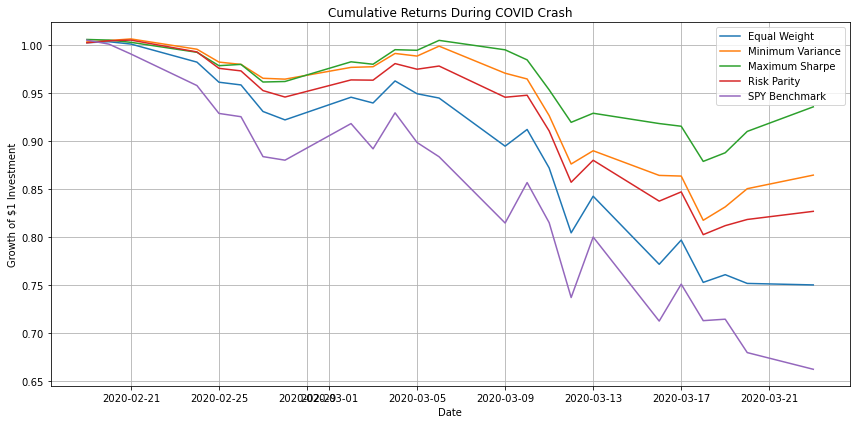

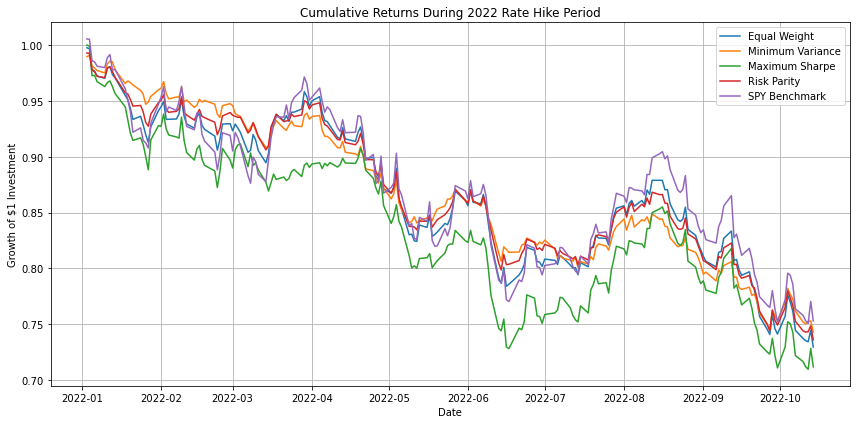

In [6]:
for period_name, (start_date, end_date) in stress_periods.items():
    period_data = backtest_returns.loc[start_date:end_date]
    cumulative = (1 + period_data).cumprod()
    
    plt.figure(figsize=(12, 6))
    
    x = cumulative.index.to_numpy()
    
    for column in cumulative.columns:
        y = cumulative[column].to_numpy()
        plt.plot(x, y, label=column)
    
    plt.title(f"Cumulative Returns During {period_name}")
    plt.xlabel("Date")
    plt.ylabel("Growth of $1 Investment")
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    
    file_name = period_name.lower().replace(" ", "_").replace("/", "_")
    plt.savefig(f"../figures/stress_test_{file_name}.png", dpi=300)
    plt.show()

In [7]:
combined_stress_summary = pd.concat(stress_results, names=["Stress Period", "Strategy"])
combined_stress_summary

Period Return  Annualized Volatility  \
Stress Period         Strategy                                                 
COVID Crash           Equal Weight          -0.250058               0.523338   
                      Minimum Variance      -0.135737               0.340343   
                      Maximum Sharpe        -0.064652               0.280444   
                      Risk Parity           -0.173443               0.372046   
                      SPY Benchmark         -0.337897               0.755206   
2022 Rate Hike Period Equal Weight          -0.270426               0.184421   
                      Minimum Variance      -0.256964               0.128717   
                      Maximum Sharpe        -0.288250               0.209520   
                      Risk Parity           -0.264019               0.149477   
                      SPY Benchmark         -0.247031               0.243660   

                                        Maximum Drawdown  95% Historical VaR  \
Stress Period         Strategy                                                 
COVID Crash           Equal Weight             -0.252417           -0.074205   
                      Minimum Variance         -0.187700           -0.051263   
                      Maximum Sharpe           -0.126249           -0.034943   
                      Risk Parity              -0.201588           -0.051944   
                      SPY Benchmark            -0.341047           -0.093040   
2022 Rate Hike Period Equal Weight             -0.268894           -0.019959   
                      Minimum Variance         -0.250182           -0.013640   
                      Maximum Sharpe           -0.290557           -0.022938   
                      Risk Parity              -0.259032           -0.015298   
                      SPY Benchmark            -0.253606           -0.028966   

                                        95% Historical CVaR  
Stress Period         Strategy                               
COVID Crash           Equal Weight                -0.080843  
                      Minimum Variance            -0.053905  
                      Maximum Sharpe              -0.037756  
                      Risk Parity                 -0.055657  
                      SPY Benchmark               -0.102550  
2022 Rate Hike Period Equal Weight                -0.026412  
                      Minimum Variance            -0.017102  
                      Maximum Sharpe              -0.031128  
                      Risk Parity                 -0.020988  
                      SPY Benchmark               -0.035170

In [8]:
combined_stress_summary.to_csv("../data/processed/stress_test_summary.csv")

## Stress Test Interpretation

The stress testing analysis evaluates strategy performance during two distinct market stress periods: the 2020 COVID crash and the 2022 rate hike period.

During the COVID crash, the SPY benchmark experienced the largest loss and the most severe drawdown, while the optimized portfolios generally provided better downside protection. The maximum Sharpe strategy performed best during this specific episode, likely because its allocation at the time was less exposed to broad equity market risk.

The 2022 rate hike period shows a different pattern. Most strategies experienced substantial losses, and diversification benefits were weaker because both equities and long-duration bonds were under pressure. This highlights that diversification benefits are regime-dependent and may weaken during periods of simultaneous equity and bond market stress.

Overall, the stress test results show that optimized portfolios can reduce downside risk during some crisis periods, but no strategy is immune to regime-specific shocks.